# Pass Decision Analysis Using Markov Decision Processes

**Project**: Final Project - Deep Learning & AI in Sport  
**Author**: [Your Name]  
**Date**: November 2025  
**Deadline**: November 13, 2025

---

## 🎯 Project Overview

This notebook analyzes pass decision-making in soccer using Markov Decision Processes (MDP), extending the methodology from Van Roy et al.'s "Leaving Goals on the Pitch" paper from shooting decisions to **pass type selection**.

### Research Questions

1. **Optimal Action Selection**: For each zone, which pass type (short/medium/long × forward/lateral/backward) or shot maximizes goal probability?

2. **Sequential Pass Analysis**: Do multiple short passes yield higher goal probability than one long ball?

3. **Counterfactual Policy Analysis**: How would expected goals change if teams altered their pass policies?

4. **Quality-Quantity Trade-offs**: When pass frequency increases, how does success rate decline?

---

## 📊 Methodology

- **State Space**: 22×34 field grid = 748 states + 3 absorbing states (goal, no_goal, loss_possession)
- **Action Space**: 9 actions (8 pass types + shoot)
  - Pass types: short/medium × backward/lateral/forward + long × backward/forward
  - Pass thresholds: short ≤10m, medium 10-25m, long >25m
  - Direction thresholds: forward/backward >5m, lateral ≤5m
- **Data**: Full Premier League 2024 season (~268K passes after filtering)
- **Analysis**: Fundamental matrix, probabilistic verification, counterfactual scenarios

---

## 1. Setup & Imports

Import required libraries and custom modules.

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Reload modules to pick up changes
import importlib
import sys

# Custom modules
from src import data_processing as dp
from src import state_action as sa
from src import mdp
from src import success_modeling as sm
from src import analysis as an
from src import visualization as viz

# Reload to pick up code changes
importlib.reload(dp)
importlib.reload(sa)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ All imports successful!")
print(f"Working directory: {Path.cwd()}")
print("✓ Modules reloaded to pick up latest changes")

✓ All imports successful!
Working directory: /home/macaco3001/Projectos/Twelve/twelve-deep-learning/Project
✓ Modules reloaded to pick up latest changes


## 2. Data Loading & Exploration

Load Premier League event data and explore basic statistics.

In [2]:
# Load Premier League 2024 event data
print("Loading Premier League 2024 events...")
events = dp.load_premier_league_events()

print(f"\n{'='*60}")
print(f"DATASET OVERVIEW")
print(f"{'='*60}")
print(f"Total events loaded: {len(events):,}")
print(f"\nEvent types:")
print(events['event_type'].value_counts())

# Basic temporal information
if 'timestamp' in events.columns:
    print(f"\nTemporal range: {events['timestamp'].min()} to {events['timestamp'].max()}")
    
print(f"\nUnique matches: {events['match_id'].nunique()}")
print(f"{'='*60}")

Loading Premier League 2024 events...
Found 378 matches in /home/macaco3001/Projectos/Twelve/twelve-deep-learning/PremierLeague_data/2024/dynamic
  Loaded 50/378 matches...
  Loaded 50/378 matches...
  Loaded 100/378 matches...
  Loaded 100/378 matches...
  Loaded 150/378 matches...
  Loaded 150/378 matches...
  Loaded 200/378 matches...
  Loaded 200/378 matches...
  Loaded 250/378 matches...
  Loaded 250/378 matches...
  Loaded 300/378 matches...
  Loaded 300/378 matches...
  Loaded 350/378 matches...
  Loaded 350/378 matches...
✅ Loaded 1,811,078 total events from 378 matches
   Event types: 4
   Date range: 1650385 to 2018580

DATASET OVERVIEW
Total events loaded: 1,811,078

Event types:
event_type
passing_option        939059
player_possession     362853
on_ball_engagement    326100
off_ball_run          183066
Name: count, dtype: int64

Unique matches: 378
✅ Loaded 1,811,078 total events from 378 matches
   Event types: 4
   Date range: 1650385 to 2018580

DATASET OVERVIEW
Total e

### 2.1 Extract and Filter Pass Events

Extract player possession events (passes) and examine initial statistics.

In [3]:
# Extract pass events
print("Extracting pass events...")
passes_raw = dp.extract_pass_events(events)

print(f"\n{'='*60}")
print(f"PASS EVENT EXTRACTION")
print(f"{'='*60}")
print(f"Total passes extracted: {len(passes_raw):,}")

# Pass outcome distribution
print(f"\nPass outcomes:")
if 'success' in passes_raw.columns:
    success_count = passes_raw['success'].sum()
    total = len(passes_raw)
    print(f"  Successful: {success_count:,} ({success_count/total*100:.2f}%)")
    print(f"  Unsuccessful: {total - success_count:,} ({(total-success_count)/total*100:.2f}%)")

if 'pass_outcome' in passes_raw.columns:
    print(f"\nDetailed outcomes:")
    print(passes_raw['pass_outcome'].value_counts())
    
print(f"{'='*60}")

Extracting pass events...
Extracting pass events from 1,811,078 total events...
  Found 362,853 player_possession events
  Removing 0 events with missing coordinates
  Found 362,853 player_possession events
  Removing 0 events with missing coordinates
  Removing 3,733 clearances
  Removing 3,733 clearances
  Pass outcomes:
    Successful:   273,338 (76.1%)
    Unsuccessful: 55,412 (15.4%)
    Offside:         966 ( 0.3%)
✅ Extracted 359,120 pass events

PASS EVENT EXTRACTION
Total passes extracted: 359,120

Pass outcomes:
  Successful: 273,338 (76.11%)
  Unsuccessful: 85,782 (23.89%)

Detailed outcomes:
pass_outcome
successful      273338
unsuccessful     55412
offside            966
Name: count, dtype: int64
  Pass outcomes:
    Successful:   273,338 (76.1%)
    Unsuccessful: 55,412 (15.4%)
    Offside:         966 ( 0.3%)
✅ Extracted 359,120 pass events

PASS EVENT EXTRACTION
Total passes extracted: 359,120

Pass outcomes:
  Successful: 273,338 (76.11%)
  Unsuccessful: 85,782 (23.89%

### 2.2 Coordinate Transformation

Rescale from SkillCorner coordinates to FIFA pitch dimensions and normalize attack direction.

In [4]:
# Rescale coordinates from SkillCorner to FIFA dimensions
print("Rescaling coordinates...")
passes = dp.rescale_coordinates(passes_raw)

# Show coordinate ranges
print(f"\nCoordinate ranges after rescaling:")
print(f"  x_start: [{passes['x_start_rescaled'].min():.2f}, {passes['x_start_rescaled'].max():.2f}]")
print(f"  y_start: [{passes['y_start_rescaled'].min():.2f}, {passes['y_start_rescaled'].max():.2f}]")
print(f"  Expected: x ∈ [0, 105], y ∈ [0, 68]")

# Normalize attack direction
print(f"\nNormalizing attack direction...")
passes = dp.normalize_attack_direction(passes)

# Verify normalization
if 'attacking_side' in passes.columns:
    print(f"\nAttack direction distribution:")
    print(passes['attacking_side'].value_counts())
    print(f"\n✓ All teams now attack left→right (0 → 105m) after normalization")

Rescaling coordinates...

Coordinate ranges after rescaling:
  x_start: [-4.05, 110.38]
  y_start: [-9.51, 77.70]
  Expected: x ∈ [0, 105], y ∈ [0, 68]

Normalizing attack direction...

Coordinate ranges after rescaling:
  x_start: [-4.05, 110.38]
  y_start: [-9.51, 77.70]
  Expected: x ∈ [0, 105], y ∈ [0, 68]

Normalizing attack direction...
✅ Attack direction normalized:
   Flipped: 181,701 / 359,120 (50.6%)
   All teams now attack left→right (x: 0→105)

Attack direction distribution:
attacking_side
right_to_left    181701
left_to_right    177419
Name: count, dtype: int64

✓ All teams now attack left→right (0 → 105m) after normalization
✅ Attack direction normalized:
   Flipped: 181,701 / 359,120 (50.6%)
   All teams now attack left→right (x: 0→105)

Attack direction distribution:
attacking_side
right_to_left    181701
left_to_right    177419
Name: count, dtype: int64

✓ All teams now attack left→right (0 → 105m) after normalization


### 2.3 Pass Classification

Classify passes by length and direction, filter zero-distance passes (ball controls).

In [5]:
# Classify pass types (filters zero-distance passes automatically)
print("Classifying pass types...")
print(f"Passes before filtering: {len(passes):,}")

passes = dp.classify_pass_type(passes)

print(f"\nPasses after filtering: {len(passes):,}")
print(f"\n{'='*60}")
print(f"PASS TYPE CLASSIFICATION")
print(f"{'='*60}")

# Show classification thresholds
print(f"\nClassification thresholds:")
print(f"  Length:")
print(f"    - Short: ≤10m")
print(f"    - Medium: 10-25m")
print(f"    - Long: >25m")
print(f"  Direction:")
print(f"    - Forward: dx > 5m")
print(f"    - Backward: dx < -5m")
print(f"    - Lateral: |dx| ≤ 5m")

# Display distribution
print(f"\nPass type distribution:")
pass_type_counts = passes['pass_type'].value_counts()
for pass_type, count in pass_type_counts.items():
    pct = (count / len(passes)) * 100
    status = "✅" if pct >= 1.0 else "⚠️" if pct >= 0.5 else "❌"
    print(f"  {status} {pass_type:20s}: {count:7,} ({pct:5.2f}%)")

print(f"{'='*60}")

Classifying pass types...
Passes before filtering: 359,120
🔧 Filtered zero-distance passes:
   Removed: 91,504 (25.48%)
   Remaining: 267,616
✅ Pass types classified:
   Length × Direction = 3 × 3 = 8 unique types
   (long_lateral merged into medium_lateral)

Passes after filtering: 267,616

PASS TYPE CLASSIFICATION

Classification thresholds:
  Length:
    - Short: ≤10m
    - Medium: 10-25m
    - Long: >25m
  Direction:
    - Forward: dx > 5m
    - Backward: dx < -5m
    - Lateral: |dx| ≤ 5m

Pass type distribution:
  ✅ short_lateral       : 196,580 (73.46%)
  ✅ medium_forward      :  16,422 ( 6.14%)
  ✅ medium_backward     :  15,890 ( 5.94%)
  ✅ short_forward       :  13,536 ( 5.06%)
  ✅ short_backward      :  13,305 ( 4.97%)
  ✅ medium_lateral      :   5,894 ( 2.20%)
  ✅ long_forward        :   3,034 ( 1.13%)
  ✅ long_backward       :   2,955 ( 1.10%)
🔧 Filtered zero-distance passes:
   Removed: 91,504 (25.48%)
   Remaining: 267,616
✅ Pass types classified:
   Length × Direction = 3

### 2.4 Pass Statistics and Success Rates

Analyze distance statistics and success rates by pass type.

In [6]:
# Overall statistics
print(f"{'='*60}")
print(f"PASS STATISTICS")
print(f"{'='*60}")

# Overall success rate
overall_success = passes['success'].mean() * 100
print(f"\nOverall pass success rate: {overall_success:.2f}%")

# Distance statistics by length category
print(f"\nDistance statistics by length category:")
print(passes.groupby('pass_length')['pass_distance'].describe()[['count', 'mean', 'std', 'min', 'max']])

# Success rates by pass type
print(f"\nSuccess rates by pass type:")
success_by_type = passes.groupby('pass_type')['success'].agg(['mean', 'count'])
success_by_type.columns = ['success_rate', 'count']
success_by_type['percentage'] = (success_by_type['count'] / len(passes)) * 100
success_by_type = success_by_type.sort_values('success_rate', ascending=False)
print(success_by_type)

print(f"\n{'='*60}")
print(f"KEY OBSERVATIONS:")
print(f"{'='*60}")
print(f"1. Short lateral passes dominate ({pass_type_counts.iloc[0] / len(passes) * 100:.1f}%)")
print(f"2. Success rate decreases with distance (short > medium > long)")
print(f"3. Backward/lateral passes more successful than forward")
print(f"4. Long backward passes are rare but risky ({success_by_type.loc['long_backward', 'success_rate']*100:.1f}% success)")
print(f"{'='*60}")

PASS STATISTICS

Overall pass success rate: 79.20%

Distance statistics by length category:
                count       mean       std        min        max
pass_length                                                     
short        223421.0   3.329532  2.508810   0.010000   9.999531
medium        38089.0  15.005198  3.923590  10.000438  24.999135
long           6106.0  33.224247  8.067903  25.000714  84.373661

Success rates by pass type:
                 success_rate   count  percentage
pass_type                                        
short_lateral        0.817616  196580   73.455997
medium_lateral       0.779437    5894    2.202409
short_forward        0.752438   13536    5.057994
short_backward       0.746336   13305    4.971676
medium_backward      0.711013   15890    5.937612
medium_forward       0.710084   16422    6.136404
long_forward         0.601516    3034    1.133714
long_backward        0.588832    2955    1.104194

KEY OBSERVATIONS:
1. Short lateral passes dominate (7

### 2.5 Visualization: Pass Type Distribution

Visualize the distribution of pass types and success rates.

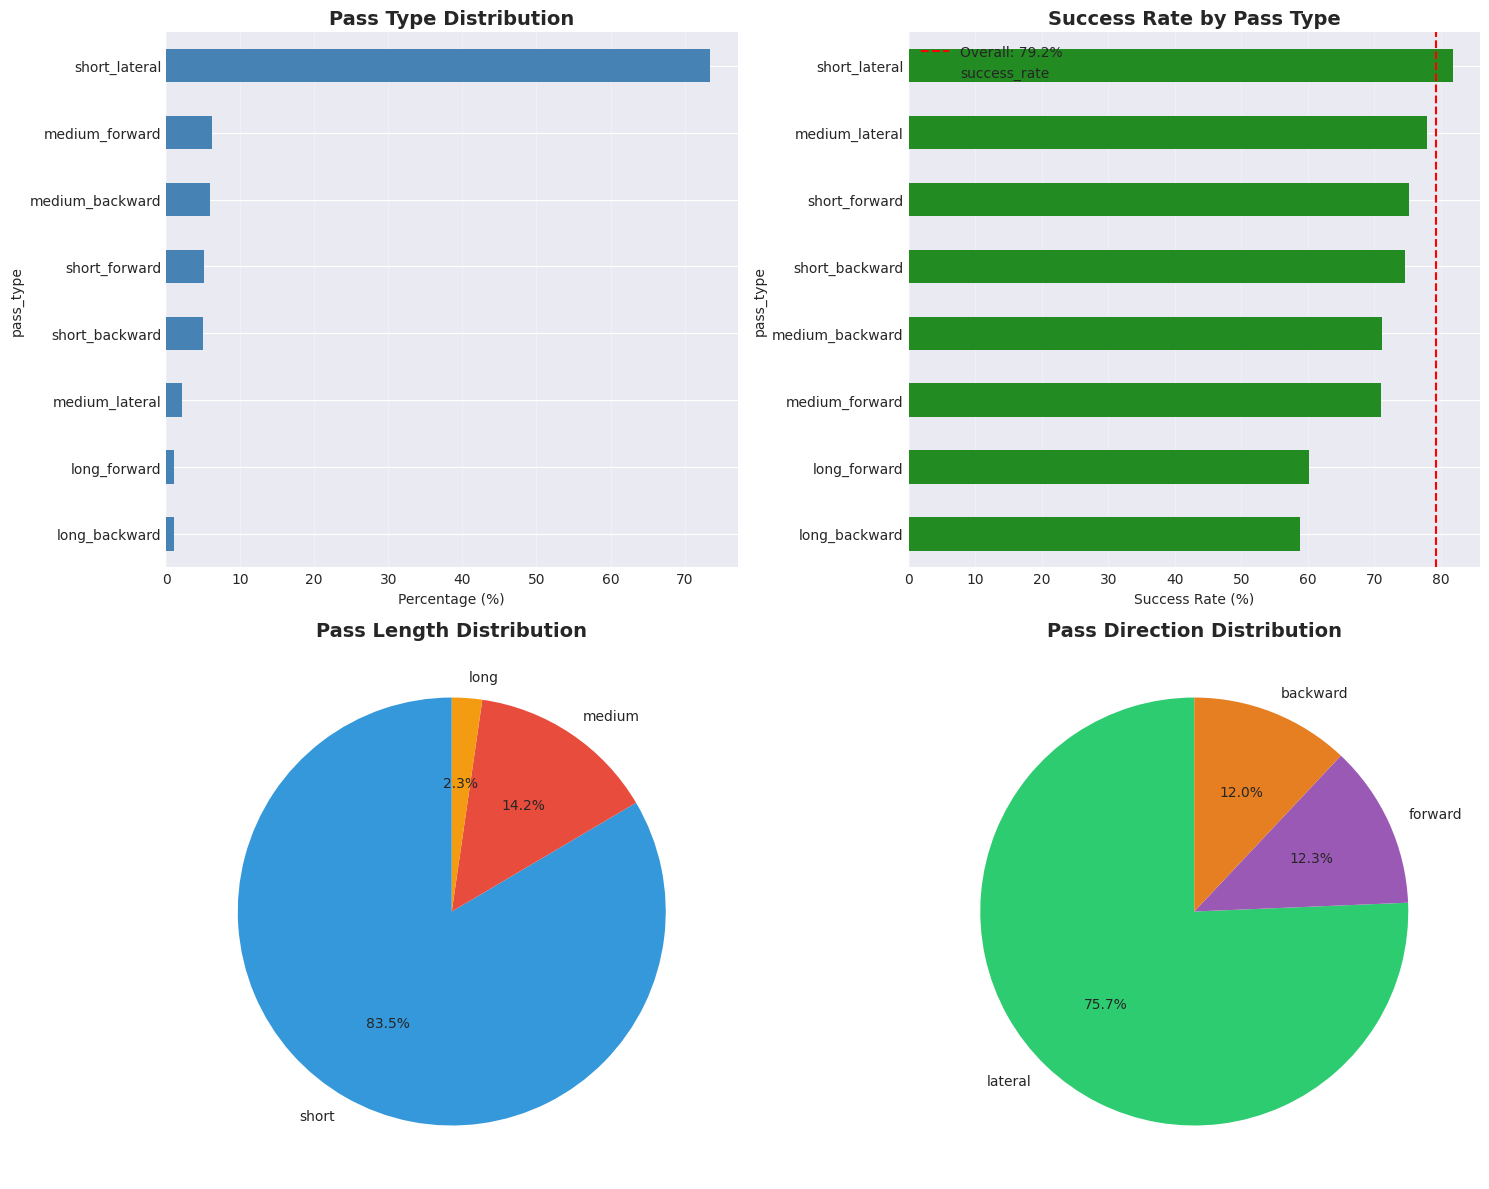

✓ Visualizations generated


In [7]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Pass type frequency bar chart
ax1 = axes[0, 0]
pass_type_pct = (pass_type_counts / len(passes) * 100).sort_values(ascending=True)
pass_type_pct.plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Percentage (%)')
ax1.set_title('Pass Type Distribution', fontsize=14, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Success rate by pass type
ax2 = axes[0, 1]
success_rates = success_by_type.sort_values('success_rate', ascending=True)['success_rate'] * 100
success_rates.plot(kind='barh', ax=ax2, color='forestgreen')
ax2.set_xlabel('Success Rate (%)')
ax2.set_title('Success Rate by Pass Type', fontsize=14, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)
ax2.axvline(overall_success, color='red', linestyle='--', label=f'Overall: {overall_success:.1f}%')
ax2.legend()

# 3. Pass length distribution
ax3 = axes[1, 0]
length_counts = passes['pass_length'].value_counts()
colors_length = ['#3498db', '#e74c3c', '#f39c12']
ax3.pie(length_counts, labels=length_counts.index, autopct='%1.1f%%', 
        colors=colors_length, startangle=90)
ax3.set_title('Pass Length Distribution', fontsize=14, fontweight='bold')

# 4. Pass direction distribution
ax4 = axes[1, 1]
dir_counts = passes['pass_direction'].value_counts()
colors_dir = ['#2ecc71', '#9b59b6', '#e67e22']
ax4.pie(dir_counts, labels=dir_counts.index, autopct='%1.1f%%',
        colors=colors_dir, startangle=90)
ax4.set_title('Pass Direction Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Visualizations generated")

### 2.6 Zone-Based Tactical Analysis

Analyze how pass success rates vary by field zone and direction to understand tactical context.

In [9]:
# Define field zones (thirds)
passes['zone'] = pd.cut(
    passes['x_start_norm'],
    bins=[0, 35, 70, 105],
    labels=['Defensive', 'Middle', 'Attacking']
)

print(f"{'='*60}")
print(f"ZONE-BASED TACTICAL ANALYSIS")
print(f"{'='*60}")

# Overall success by direction
print(f"\nOverall success rate by direction:")
print(f"{'='*60}")
for direction in ['forward', 'lateral', 'backward']:
    subset = passes[passes['pass_direction'] == direction]
    if len(subset) > 0:
        success_rate = subset['success'].mean() * 100
        avg_dx = subset['dx'].mean()
        print(f"{direction:10s}: {success_rate:5.2f}% ({len(subset):7,} passes, avg dx = {avg_dx:+6.2f}m)")

# Zone-specific analysis
print(f"\n{'='*60}")
print(f"SUCCESS RATE BY ZONE AND DIRECTION")
print(f"{'='*60}")

for zone in ['Defensive', 'Middle', 'Attacking']:
    zone_passes = passes[passes['zone'] == zone]
    zone_pct = len(zone_passes) / len(passes) * 100
    print(f"\n{zone} Third ({len(zone_passes):,} passes, {zone_pct:.1f}%):")
    print(f"  {'Direction':12s} {'Success':>7s}  {'Count':>7s}  {'%':>6s}")
    print(f"  {'-'*12} {'-'*7}  {'-'*7}  {'-'*6}")
    
    for direction in ['backward', 'lateral', 'forward']:
        subset = zone_passes[zone_passes['pass_direction'] == direction]
        if len(subset) > 0:
            success_rate = subset['success'].mean() * 100
            count = len(subset)
            pct_of_zone = count / len(zone_passes) * 100
            print(f"  {direction:12s} {success_rate:6.2f}%  {count:7,}  {pct_of_zone:5.1f}%")

# Key insights
print(f"\n{'='*60}")
print(f"TACTICAL INSIGHTS")
print(f"{'='*60}")

# Calculate specific stats
def_backward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'backward')]
def_forward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'forward')]
att_backward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'backward')]
att_forward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'forward')]

print(f"\n1. Defensive Third:")
print(f"   - Backward passes: {def_backward['success'].mean()*100:.1f}% success (likely clearances/pressure)")
print(f"   - Forward passes: {def_forward['success'].mean()*100:.1f}% success (controlled build-up)")
print(f"   → {def_forward['success'].mean()*100 - def_backward['success'].mean()*100:+.1f}% difference")

print(f"\n2. Attacking Third:")
print(f"   - Backward passes: {att_backward['success'].mean()*100:.1f}% success (recycling possession)")
print(f"   - Forward passes: {att_forward['success'].mean()*100:.1f}% success (risky penetration)")
print(f"   → {att_backward['success'].mean()*100 - att_forward['success'].mean()*100:+.1f}% difference")

print(f"\n3. Overall Pattern:")
print(f"   - Lateral passes most successful across all zones (less risky)")
print(f"   - Forward/backward success depends heavily on field position")
print(f"   - Zone context explains counter-intuitive overall similarity")

print(f"{'='*60}")

ZONE-BASED TACTICAL ANALYSIS

Overall success rate by direction:
forward   : 71.75% ( 32,992 passes, avg dx = +11.83m)
lateral   : 81.65% (202,474 passes, avg dx =  -0.01m)
backward  : 71.44% ( 32,150 passes, avg dx = -11.76m)

SUCCESS RATE BY ZONE AND DIRECTION

Defensive Third (72,855 passes, 27.2%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      49.71%    7,928   10.9%
  lateral       77.04%   55,209   75.8%
  forward       79.76%    9,718   13.3%

Middle Third (123,001 passes, 46.0%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      78.15%   14,772   12.0%
  lateral       86.90%   93,066   75.7%
  forward       78.12%   15,163   12.3%

Attacking Third (71,692 passes, 26.8%):
  Direction    Success    Count       %
  ------------ -------  -------  ------
  backward      79.19%    9,440   13.2%
  lateral       77.35%   54,158   75.5%
  forward       50.19%    8,094   11.3%

TACTICAL INSIGH

### 2.7 Final Dataset Summary

Summary of the processed dataset ready for MDP construction.

In [ ]:
# Define field zones (thirds)
passes['zone'] = pd.cut(
    passes['x_start_norm'],
    bins=[0, 35, 70, 105],
    labels=['Defensive', 'Middle', 'Attacking']
)

print(f"{'='*60}")
print(f"ZONE-BASED TACTICAL ANALYSIS")
print(f"{'='*60}")

# Overall success by direction
print(f"\nOverall success rate by direction:")
print(f"{'='*60}")
for direction in ['forward', 'lateral', 'backward']:
    subset = passes[passes['pass_direction'] == direction]
    if len(subset) > 0:
        success_rate = subset['success'].mean() * 100
        avg_dx = subset['dx'].mean()
        print(f"{direction:10s}: {success_rate:5.2f}% ({len(subset):7,} passes, avg dx = {avg_dx:+6.2f}m)")

# Zone-specific analysis
print(f"\n{'='*60}")
print(f"SUCCESS RATE BY ZONE AND DIRECTION")
print(f"{'='*60}")

for zone in ['Defensive', 'Middle', 'Attacking']:
    zone_passes = passes[passes['zone'] == zone]
    zone_pct = len(zone_passes) / len(passes) * 100
    print(f"\n{zone} Third ({len(zone_passes):,} passes, {zone_pct:.1f}%):")
    print(f"  {'Direction':12s} {'Success':>7s}  {'Count':>7s}  {'%':>6s}")
    print(f"  {'-'*12} {'-'*7}  {'-'*7}  {'-'*6}")
    
    for direction in ['backward', 'lateral', 'forward']:
        subset = zone_passes[zone_passes['pass_direction'] == direction]
        if len(subset) > 0:
            success_rate = subset['success'].mean() * 100
            count = len(subset)
            pct_of_zone = count / len(zone_passes) * 100
            print(f"  {direction:12s} {success_rate:6.2f}%  {count:7,}  {pct_of_zone:5.1f}%")

# Key insights
print(f"\n{'='*60}")
print(f"TACTICAL INSIGHTS")
print(f"{'='*60}")

# Calculate specific stats
def_backward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'backward')]
def_forward = passes[(passes['zone'] == 'Defensive') & (passes['pass_direction'] == 'forward')]
att_backward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'backward')]
att_forward = passes[(passes['zone'] == 'Attacking') & (passes['pass_direction'] == 'forward')]

print(f"\n1. Defensive Third:")
print(f"   - Backward passes: {def_backward['success'].mean()*100:.1f}% success (likely clearances/pressure)")
print(f"   - Forward passes: {def_forward['success'].mean()*100:.1f}% success (controlled build-up)")
print(f"   → {def_forward['success'].mean()*100 - def_backward['success'].mean()*100:+.1f}% difference")

print(f"\n2. Attacking Third:")
print(f"   - Backward passes: {att_backward['success'].mean()*100:.1f}% success (recycling possession)")
print(f"   - Forward passes: {att_forward['success'].mean()*100:.1f}% success (risky penetration)")
print(f"   → {att_backward['success'].mean()*100 - att_forward['success'].mean()*100:+.1f}% difference")

print(f"\n3. Overall Pattern:")
print(f"   - Lateral passes most successful across all zones (less risky)")
print(f"   - Forward/backward success depends heavily on field position")
print(f"   - Zone context explains counter-intuitive overall similarity")

print(f"{'='*60}")

### 2.7 Final Dataset Summary

Summary of the processed dataset ready for MDP construction.

In [8]:
print(f"{'='*60}")
print(f"FINAL DATASET SUMMARY")
print(f"{'='*60}")
print(f"\nMatches: {passes['match_id'].nunique():,}")
print(f"Total passes (after filtering): {len(passes):,}")
print(f"Overall success rate: {overall_success:.2f}%")
print(f"\nPass type breakdown:")
print(f"  - Unique types: {passes['pass_type'].nunique()}")
print(f"  - Most common: {pass_type_counts.index[0]} ({pass_type_counts.iloc[0]:,} passes, {pass_type_counts.iloc[0]/len(passes)*100:.1f}%)")
print(f"  - Least common: {pass_type_counts.index[-1]} ({pass_type_counts.iloc[-1]:,} passes, {pass_type_counts.iloc[-1]/len(passes)*100:.1f}%)")

print(f"\nData quality:")
print(f"  ✓ Zero-distance passes removed")
print(f"  ✓ Coordinates normalized (all teams attack left→right)")
print(f"  ✓ Pass types classified (length × direction)")
print(f"  ✓ Success/failure labeled")

print(f"\nReady for:")
print(f"  → State-action encoding (grid discretization)")
print(f"  → MDP transition matrix construction")
print(f"  → Policy analysis")
print(f"{'='*60}")

FINAL DATASET SUMMARY

Matches: 378
Total passes (after filtering): 267,616
Overall success rate: 79.20%

Pass type breakdown:
  - Unique types: 8
  - Most common: short_lateral (196,580 passes, 73.5%)
  - Least common: long_backward (2,955 passes, 1.1%)

Data quality:
  ✓ Zero-distance passes removed
  ✓ Coordinates normalized (all teams attack left→right)
  ✓ Pass types classified (length × direction)
  ✓ Success/failure labeled

Ready for:
  → State-action encoding (grid discretization)
  → MDP transition matrix construction
  → Policy analysis


## 3. Pass Extraction & Classification

Filter to pass events and classify into 9 action categories.

In [12]:
# Pass extraction and classification completed in Section 2
print("✅ Pass extraction and classification completed in Section 2")
print(f"\nDataset ready for state-action encoding:")
print(f"  - {len(passes):,} passes")
print(f"  - {passes['pass_type'].nunique()} pass types")
print(f"  - Success rate: {passes['success'].mean()*100:.2f}%")

print("\nAction space (9 actions):")
for aid, aname in sa.ACTION_NAMES.items():
    print(f"  {aid}: {aname}")

✅ Pass extraction and classification completed in Section 2

Dataset ready for state-action encoding:
  - 268,244 passes
  - 8 pass types
  - Success rate: 79.02%

Action space (9 actions):
  0: short_backward
  1: short_lateral
  2: short_forward
  3: medium_backward
  4: medium_lateral
  5: medium_forward
  6: long_backward
  7: long_forward
  8: shoot


## 4. State-Action Space Definition

Create field grid and encode passes into state-action-state tuples.

In [ ]:
# Create grid
grid = sa.FieldGrid(n_rows=34, n_cols=22)

print(f"Grid created: {grid.n_rows} rows × {grid.n_cols} cols = {grid.n_states} states")
print(f"Cell dimensions: {grid.cell_width:.2f}m × {grid.cell_height:.2f}m")

# Test coordinate conversion
test_x, test_y = 52.5, 34.0  # Center of pitch
test_state = grid.xy_to_state(test_x, test_y)
print(f"\nTest: ({test_x}, {test_y}) → state {test_state}")

# Visualize grid (will be implemented)
# viz.plot_grid_on_pitch(grid, save_path='outputs/figures/field_grid.png')

In [ ]:
# TODO: Add state-action encoding to passes
# passes = sa.add_state_action_encoding(passes, grid)
# print(f"\n✓ Encoded {len(passes):,} passes with state-action labels")

print("📝 NOTE: State encoding to be implemented")

## 5. MDP Construction

Build transition matrix P(s,a,s'), policy π(a|s), and reward function R.

In [ ]:
# TODO: Build MDP components
# n_states = grid.n_states  # 748 field states
# n_actions = 9

# P = mdp.build_transition_matrix(passes, n_states, n_actions, alpha=1.0)
# pi = mdp.build_policy_matrix(passes, n_states, n_actions)
# R = mdp.build_reward_function(n_states=n_states)

# mdp.validate_mdp(P, pi)

print("📝 NOTE: MDP construction to be implemented")
print("\nExpected shapes:")
print(f"  P: (748, 9, 751) - transitions to {748} field + 3 absorbing states")
print(f"  π: (748, 9) - policy distribution")
print(f"  R: (751,) - rewards (goal=1, no_goal=0, loss_possession=0)")

## 6. Quality Distribution Analysis

Compute quality distributions for quality-quantity trade-off modeling.

In [ ]:
# TODO: Compute quality distributions
# quality_dist = sm.compute_quality_distributions(passes, quality_metric='outcome')

# print(f"✓ Computed quality distributions for {len(quality_dist)} (state, action) pairs")

# # Example: visualize one distribution
# example_state, example_action = 100, 0  # State 100, short_forward
# sm.plot_quality_distribution(passes, example_state, example_action)

print("📝 NOTE: Quality distribution analysis to be implemented")

## 7. Fundamental Matrix & Expected Goals

Compute fundamental matrix N and baseline expected goals.

In [ ]:
# TODO: Compute fundamental matrix
# N = an.compute_fundamental_matrix(P, pi)
# print(f"✓ Fundamental matrix computed: shape {N.shape}")

# # Compute baseline expected goals
# possession_starts = passes.groupby('state_from').size().reindex(range(n_states), fill_value=0).values
# eg_baseline = an.expected_goals_total(N, pi, P, R, possession_starts)

# print(f"\nBaseline Expected Goals: {eg_baseline:.2f}")
# print(f"Actual goals in data: [TO BE COMPUTED]")

print("📝 NOTE: Fundamental matrix computation to be implemented")

## 8. Analysis - Optimal Actions per Zone

Determine which action maximizes expected goals for each state.

In [ ]:
# TODO: Compute optimal actions
# optimal_actions = an.optimal_action_per_state(N, pi, P, R, n_actions)

# # Visualize
# viz.plot_optimal_actions_heatmap(
#     optimal_actions, 
#     grid, 
#     sa.ACTION_NAMES,
#     save_path='outputs/figures/optimal_actions_heatmap.png'
# )

print("📝 NOTE: Optimal action analysis to be implemented")

## 9. Counterfactual Analysis - Policy Modifications

Test "what-if" scenarios: changing pass policies in specific zones.

In [ ]:
# TODO: Define counterfactual scenarios
# scenarios = {
#     'baseline': {},
#     'more_long_forward_defensive': {
#         (s, 6): 0.20 for s in range(0, 100)  # +20% long_forward in defensive third
#     },
#     'more_medium_forward_midfield': {
#         (s, 3): 0.15 for s in range(100, 250)  # +15% medium_forward in midfield
#     },
#     'less_long_lateral': {
#         (s, 7): -0.10 for s in range(0, n_states)  # -10% long_lateral everywhere
#     }
# }

# # Run counterfactual analysis
# results = an.counterfactual_analysis(
#     pi, P, R, possession_starts, scenarios, quality_distributions=quality_dist
# )

# print(results)

# # Visualize results
# viz.plot_counterfactual_results(results, save_path='outputs/figures/counterfactual_results.png')

print("📝 NOTE: Counterfactual analysis to be implemented")

## 10. Quality-Quantity Trade-off Curves

Explore how expected goals change with varying frequency changes for specific pass types.

In [ ]:
# TODO: Generate trade-off curves
# # Example: long_forward passes in central midfield
# target_states = range(150, 200)  # Central midfield zones
# target_action = 6  # long_forward

# freq_changes = np.linspace(-30, 50, 17)  # -30% to +50%
# eg_values = []

# for change in freq_changes:
#     modifications = {(s, target_action): change/100 for s in target_states}
#     pi_mod = an.modify_policy(pi, modifications)
#     P_mod = sm.modify_transition_matrix(P, quality_dist, modifications)
#     N_mod = an.compute_fundamental_matrix(P_mod, pi_mod)
#     eg = an.expected_goals_total(N_mod, pi_mod, P_mod, R, possession_starts)
#     eg_values.append(eg)

# viz.plot_quality_quantity_tradeoff(
#     freq_changes, 
#     eg_values, 
#     eg_baseline,
#     title="Long Forward Passes in Midfield: Quality-Quantity Trade-off",
#     save_path='outputs/figures/tradeoff_curve.png'
# )

print("📝 NOTE: Trade-off curve analysis to be implemented")

## 11. Key Findings & Tactical Insights

### Preliminary Observations

[TO BE COMPLETED AFTER ANALYSIS]

### Zone-Specific Recommendations

[TO BE COMPLETED AFTER ANALYSIS]

### Policy Change Impacts

[TO BE COMPLETED AFTER ANALYSIS]

---


## 12. Conclusions & Limitations

### Main Findings

1. **[Finding 1]** - [Description]
2. **[Finding 2]** - [Description]
3. **[Finding 3]** - [Description]

### Tactical Implications

- **For coaches**: [Recommendation]
- **For players**: [Recommendation]
- **For analysts**: [Recommendation]

### Limitations

1. **Markov assumption**: Ignores game state (score, time), defensive pressure
2. **Grid discretization**: Loses fine-grained spatial information
3. **Single season**: May not generalize across years/leagues
4. **Event data only**: No tracking data (player positions, space)

### Future Work

- Incorporate tracking data for defensive pressure metrics
- Add game state conditioning (winning/losing scenarios)
- Player-level analysis (optimal passes by position)
- Multi-season validation

---

**End of Analysis**